# Sesión 13 — Transformers I: Secuencias y Atención

En esta sesión construiremos la **intuición** y la mecánica base de la atención:
- Tokens → embeddings
- Proyecciones **Q, K, V**
- **Scaled dot-product attention**
- Visualización de pesos de atención
- **Multi-head attention** (conceptual)
- **Positional encoding** (implementación)
- **Máscaras causales** (autoregresión)

Objetivo: que puedas mirar una matriz de atención y explicar qué está ocurriendo.


In [1]:
# Imports
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math


## 1) Secuencia de ejemplo

Simulamos una secuencia de **N tokens**, cada uno con embedding de dimensión **d_model**.
(Por ahora no hacemos tokenización real; nos enfocamos en el mecanismo.)

In [2]:
torch.manual_seed(0)
N = 6
d_model = 16
X = torch.randn(N, d_model)
X.shape

torch.Size([6, 16])

## 2) Proyecciones Q, K, V

Para cada token creamos tres proyecciones lineales:
- **Q** (Query): lo que busco
- **K** (Key): lo que ofrezco
- **V** (Value): lo que transmito

In [3]:
# Matrices de proyección (como si fueran capas lineales sin bias)
Wq = torch.randn(d_model, d_model)
Wk = torch.randn(d_model, d_model)
Wv = torch.randn(d_model, d_model)

Q = X @ Wq
K = X @ Wk
V = X @ Wv

Q.shape, K.shape, V.shape

(torch.Size([6, 16]), torch.Size([6, 16]), torch.Size([6, 16]))

## 3) Scaled dot-product attention

Computamos similitudes Q·K y normalizamos con softmax:

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [4]:
d_k = d_model
scores = (Q @ K.T) / (d_k ** 0.5)   # (N x N)
weights = F.softmax(scores, dim=-1)
out = weights @ V                  # (N x d_model)

scores.shape, weights.shape, out.shape

(torch.Size([6, 6]), torch.Size([6, 6]), torch.Size([6, 16]))

## 4) Visualización: matriz de atención

Cada fila (query) muestra a qué posiciones (keys) presta atención ese token.

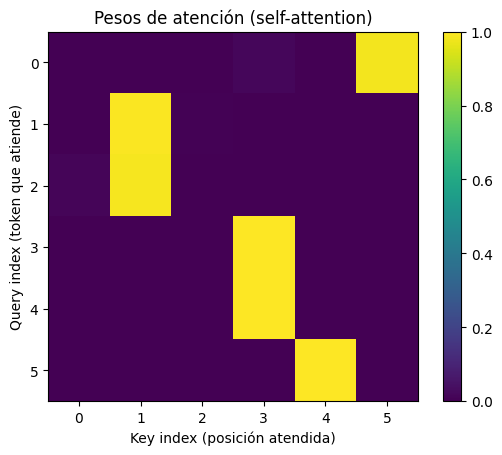

In [5]:
plt.figure()
plt.imshow(weights.detach().cpu())
plt.colorbar()
plt.title('Pesos de atención (self-attention)')
plt.xlabel('Key index (posición atendida)')
plt.ylabel('Query index (token que atiende)')
plt.show()

## 5) Inspección rápida

Veamos, por ejemplo, qué posiciones recibe más peso para el token en la posición 0.

In [6]:
i = 0
w = weights[i].detach()
top = torch.topk(w, k=3)
top

torch.return_types.topk(
values=tensor([9.8079e-01, 1.9116e-02, 9.0127e-05]),
indices=tensor([5, 3, 2]))

## 6) Multi-Head Attention (Conceptual)

En lugar de usar **una sola** atención, dividimos el embedding en **múltiples cabezas**.
Cada cabeza aprende un patrón diferente.

$$
d_k = \frac{d_{model}}{\text{num\_heads}}
$$

In [7]:
def split_into_heads(x, num_heads):
    """Divide embedding dimension into heads"""
    batch_size = 1  # para simplificar
    seq_len, d_model = x.size()
    d_k = d_model // num_heads
    
    # Reshape: (seq_len, d_model) -> (seq_len, num_heads, d_k)
    x = x.view(seq_len, num_heads, d_k)
    # Transpose: (num_heads, seq_len, d_k)
    return x.transpose(0, 1)

# Ejemplo: dividir en 2 cabezas
num_heads = 2
X_heads = split_into_heads(X, num_heads)
print(f"Shape original: {X.shape}")
print(f"Shape con cabezas: {X_heads.shape}")  # (num_heads, seq_len, d_k)

# Cada cabeza puede aprender un patrón diferente
# Por ejemplo: cabeza 0 detecta sintaxis, cabeza 1 detecta semántica

Shape original: torch.Size([6, 16])
Shape con cabezas: torch.Size([2, 6, 8])


**¿Por qué multi-head?**
- Permite atender a **múltiples aspectos** simultáneamente
- Cada cabeza aprende **relaciones diferentes** (ej: sintaxis vs semántica)
- Aumenta la **capacidad** del modelo sin multiplicar parámetros linealmente

## 7) Positional Encoding

La atención es **invariante al orden** de los tokens.
Necesitamos agregar información de posición.

$$
PE_{(pos, 2i)} = \sin\left(pos / 10000^{2i/d_{model}}\right)
$$
$$
PE_{(pos, 2i+1)} = \cos\left(pos / 10000^{2i/d_{model}}\right)
$$

Positional encoding shape: torch.Size([20, 16])


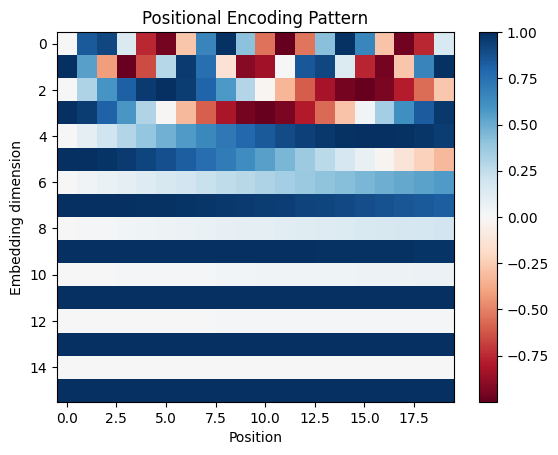

In [8]:
def get_positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

# Generar positional encoding
pe = get_positional_encoding(20, 16)
print(f"Positional encoding shape: {pe.shape}")

# Visualización
plt.imshow(pe.T, aspect='auto', cmap='RdBu')
plt.colorbar()
plt.title('Positional Encoding Pattern')
plt.xlabel('Position')
plt.ylabel('Embedding dimension')
plt.show()

In [9]:
# Agregar positional encoding a los embeddings
X_with_pos = X + pe[:X.size(0), :]

print(f"\nEmbedding original:\n{X[0, :5]}")
print(f"\nCon positional encoding:\n{X_with_pos[0, :5]}")


Embedding original:
tensor([-1.1258, -1.1524, -0.2506, -0.4339,  0.8487])

Con positional encoding:
tensor([-1.1258, -0.1524, -0.2506,  0.5661,  0.8487])


**¿Por qué funciona?**
- Las funciones **sin/cos** tienen frecuencias diferentes para cada dimensión
- Permiten al modelo **distinguir posiciones relativas**
- Son **determinísticas** y permiten extrapolación a secuencias más largas

## 8) Máscaras Causales (Autoregresión)

En modelos autoregresivos (p. ej. GPT), el token $i$ **no puede mirar** posiciones futuras $j > i$.

Aplicamos una máscara triangular superior antes del softmax.

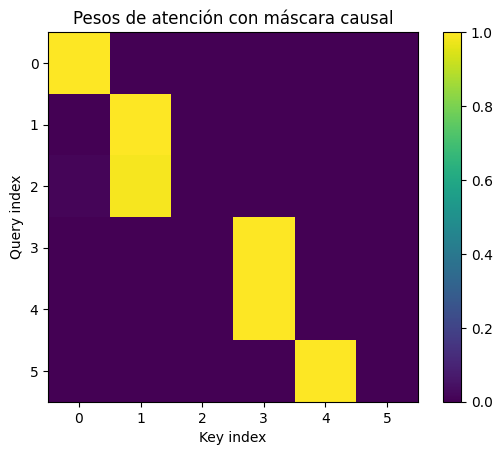

In [10]:
mask = torch.triu(torch.ones(N, N), diagonal=1).bool()
scores_masked = scores.clone()
scores_masked[mask] = -1e9  # -inf en las posiciones futuras
weights_causal = F.softmax(scores_masked, dim=-1)

plt.figure()
plt.imshow(weights_causal.detach().cpu())
plt.colorbar()
plt.title('Pesos de atención con máscara causal')
plt.xlabel('Key index')
plt.ylabel('Query index')
plt.show()

### Comparación: Con y sin máscara

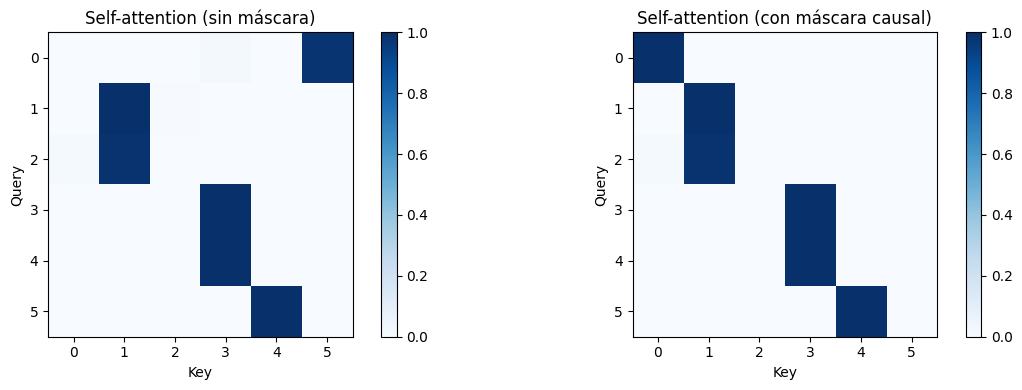

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Sin máscara
im1 = ax1.imshow(weights.detach(), cmap='Blues')
ax1.set_title('Self-attention (sin máscara)')
ax1.set_xlabel('Key')
ax1.set_ylabel('Query')
plt.colorbar(im1, ax=ax1)

# Con máscara causal
im2 = ax2.imshow(weights_causal.detach(), cmap='Blues')
ax2.set_title('Self-attention (con máscara causal)')
ax2.set_xlabel('Key')
ax2.set_ylabel('Query')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

**Observación:**
- Sin máscara: todos los tokens pueden atender a todos
- Con máscara: solo pueden mirar al **pasado y presente** (triangular inferior)
- Esto es esencial para **generación autoregresiva** (GPT, etc.)

## Preguntas de repaso

1. ¿Qué significa que un token tenga pesos de atención concentrados en una sola posición?
2. ¿Por qué escalamos por $\sqrt{d_k}$?
3. ¿Qué cambia al introducir máscara causal?
4. ¿Por qué necesitamos positional encoding?
5. ¿Qué ventaja tiene multi-head attention sobre single-head?

## Resumen

En esta sesión hemos visto:
1. ✅ **Q, K, V** y scaled dot-product attention
2. ✅ Visualización de matrices de atención
3. ✅ **Multi-head attention** (conceptualmente)
4. ✅ **Positional encoding** (sinusoidal)
5. ✅ **Máscaras causales** para autoregresión

**Próxima sesión:** Construiremos el transformer completo con estos bloques.